In [1]:
import pandas as pd
import json

import matplotlib.pyplot as plt
from matplotlib import font_manager
import os

In [2]:
# Paramètres pour les graphiques
font_dir = "assets"

for file in os.listdir(font_dir):
    if file.endswith(".ttf"):
        font_manager.fontManager.addfont(os.path.join(font_dir, file))

plt.rcParams["font.family"] = "Marianne"
plt.rcParams.update({
    "font.family": "Marianne",

    "axes.titlesize": 16,
    "axes.titleweight": "bold",

    "figure.titlesize": 18,
    "figure.titleweight": "bold",

    "axes.labelsize": 12,
    "axes.labelweight": "regular",

    "xtick.labelsize": 10,
    "ytick.labelsize": 10,

    "legend.fontsize": 10,
})

# Colors and styles for plotting
palette = {
    "Solar":      "#d66b0d",
    "Hydro":        "#2672b0",
    "Onshore":      "#72cbb7",
    "Offshore":     "#4d8377",
    "H2_CCG":       "#e4a701",
    "H2_TAC":       "#f0c040",
    "STEP_charge":  "#7a1616",
    "Fond":         "#ffffff",
    "STEP_discharge": "#ff0000",
    "Battery_charge": "#4B1063",
    "Battery_discharge": "#d126c9",
    "Battery" : "#8226A7",
}

# Colonnes production (positives)
prod_cols = [
    'H2_CCG','H2_TAC','Hydro','Onshore','Offshore',
    'STEP_discharge','Battery_discharge','Solar'
]

# Colonnes charge
charge_cols = [
    'STEP_charge','Battery_charge'
]

In [42]:
timing_1 = "results/timing_logB939D933_ancien_xlsx_loading_HiGHS.csv"
timing_2 = "results/timing_log5BB0587E_chargement_enRAM_au_début.csv"
timing_3 = "results/timing_log_60193D33_ancienXlSX_laoding_sans_start_value.csv"
timing_4 = "results/timing_log_D8B55459_Gurobi_sans_start_value_chargement_ram.csv"
timing_5 = "results/timing_log45C8DE08_nouveaux_hyperparamètres_HiGHS_parallel.csv"

timing_df = pd.read_csv(timing_1, sep=";")
timing_df_2 = pd.read_csv(timing_2, sep=";")
timing_df_3 = pd.read_csv(timing_3, sep=";")
timing_df_4 = pd.read_csv(timing_4, sep=";")
timing_df_5 = pd.read_csv(timing_5, sep=";")

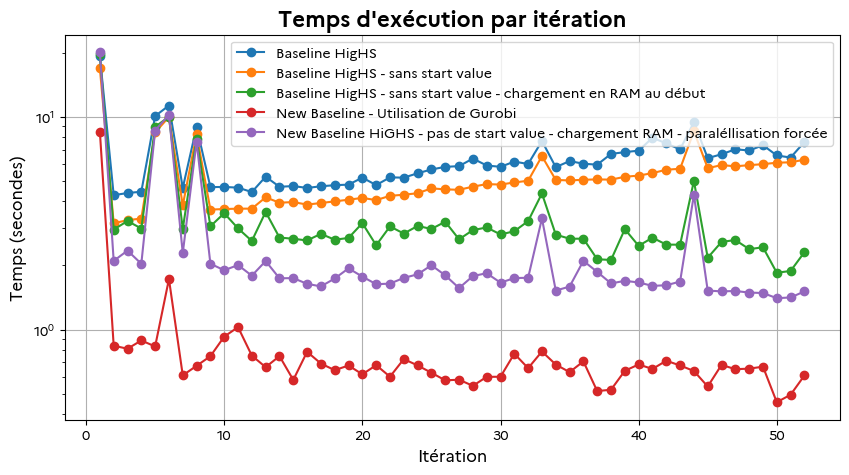

In [44]:
plt.figure(figsize=(10, 5))
plt.plot(timing_df["iteration"], timing_df["temps_secondes"], marker='o', label="Baseline HigHS")
plt.plot(timing_df_3["iteration"], timing_df_3["temps_secondes"], marker='o', label="Baseline HigHS - sans start value")
plt.plot(timing_df_2["iteration"], timing_df_2["temps_secondes"], marker='o', label="Baseline HigHS - sans start value - chargement en RAM au début")
plt.plot(timing_df_4["iteration"], timing_df_4["temps_secondes"], marker='o', label="New Baseline - Utilisation de Gurobi")
plt.plot(timing_df_5["iteration"], timing_df_5["temps_secondes"], marker='o', label="New Baseline HiGHS - pas de start value - chargement RAM - paraléllisation forcée")
plt.grid()
plt.xlabel("Itération")
plt.ylabel("Temps (secondes)")
plt.title("Temps d'exécution par itération")
plt.yscale("log")  # Utilisation d'une échelle logarithmique pour mieux visualiser les différences
plt.legend()